# 03 — Enrichment & Charts

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
from sklearn.metrics import silhouette_score, silhouette_samples
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import joblib
from ml_utils import clean_price, extract_sqft, CLUSTER_COLORS

apt = pd.read_csv("apt_clean.csv")
city_stats = pd.read_csv("city_stats_stage2.csv")
district_stats = pd.read_csv("district_stats_stage2.csv")
kmeans = joblib.load("kmeans_model.pkl")
scaler = joblib.load("scaler.pkl")

cities = pd.read_csv("cities.csv")

X = city_stats[["avg_price_per_sqft"]]
X_scaled = scaler.transform(X)

label_map = city_stats.drop_duplicates("cluster").set_index("cluster")["cluster_label"].to_dict()

apt_all = pd.read_csv("properties.csv")
apt_all = apt_all[(apt_all["type"]=="for_sale") & (apt_all["category"].str.contains("Apartment", case=False, na=False))].copy()
apt_all["price_clean"] = clean_price(apt_all["price"])
apt_all = apt_all.dropna(subset=["price_clean"])
apt_all = apt_all[apt_all["price_clean"] > 1_000_000]
apt_all["sqft"] = apt_all["properties"].apply(extract_sqft)
apt_all = apt_all.dropna(subset=["sqft"])
apt_all = apt_all[apt_all["sqft"] > 100]
price_per_sqft_before_outliers = apt_all["price_clean"] / apt_all["sqft"]

print("Loaded successfully:", city_stats.shape, district_stats.shape)

Loaded successfully: (44, 6) (6, 5)


## 10. Postal Codes & Coordinates

In [2]:
cities["name_clean"] = cities["name_en"].str.strip().str.title()
cities["name_for_match"] = cities["name_clean"].str.replace(" City", "", regex=False)

city_stats["city_for_match"] = city_stats["city_clean"].str.replace(" City", "", regex=False)

enrich_cols = ["name_for_match", "postcode", "latitude", "longitude"]
merged = city_stats.merge(
    cities[enrich_cols].drop_duplicates(subset="name_for_match"),
    left_on="city_for_match", right_on="name_for_match", how="left"
)

print(f"Postal code matched: {merged['postcode'].notna().sum()} / {len(merged)}")
print(f"Coordinates matched: {merged['latitude'].notna().sum()} / {len(merged)}")
print("Unmatched:", merged[merged['postcode'].isna()]['city_clean'].tolist())

Postal code matched: 41 / 44
Coordinates matched: 41 / 44
Unmatched: ['Angoda', 'Kiribathgoda', 'Kotte']


In [3]:
manual_data = {
    "Angoda":       {"postcode": 10620, "latitude": 6.9367, "longitude": 79.9269},
    "Kotte":        {"postcode": 10100, "latitude": 6.9170, "longitude": 79.9170},
    "Kiribathgoda": {"postcode": 11600, "latitude": 6.9781, "longitude": 79.9961},  # postcode: low-confidence, see note above
}

for city, vals in manual_data.items():
    for col, val in vals.items():
        merged.loc[merged["city_clean"] == city, col] = val

# Drop duplicate coordinate rows if cities.csv had more than one entry for a city name
merged = merged.drop_duplicates(subset="city_clean", keep="first").reset_index(drop=True)

print(f"Final postal code coverage: {merged['postcode'].notna().sum()} / {len(merged)}")
print(f"Final coordinate coverage: {merged['latitude'].notna().sum()} / {len(merged)}")

Final postal code coverage: 44 / 44
Final coordinate coverage: 44 / 44


## 11. Charts

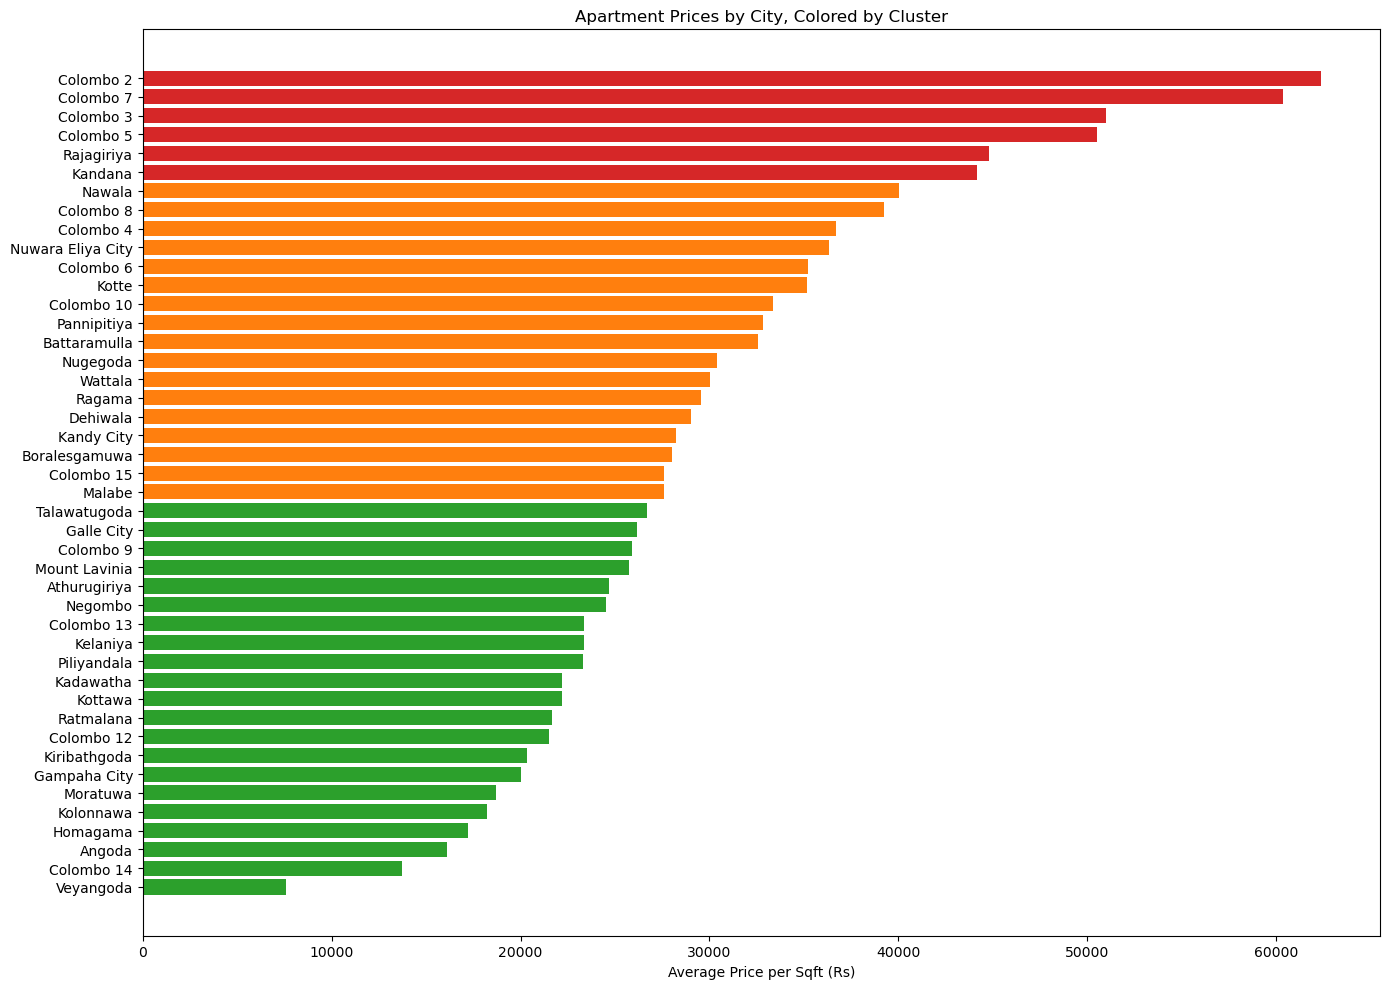

In [ ]:
colors = CLUSTER_COLORS  # imported from ml_utils

plt.figure(figsize=(14, 10))
sorted_data = merged.sort_values("avg_price_per_sqft", ascending=True)
plt.barh(sorted_data["city_clean"], sorted_data["avg_price_per_sqft"],
         color=[colors[c] for c in sorted_data["cluster_label"]])
plt.xlabel("Average Price per Sqft (Rs)")
plt.title("Apartment Prices by City, Colored by Cluster")
plt.tight_layout()
plt.savefig("chart_price_by_city.png")
plt.show()

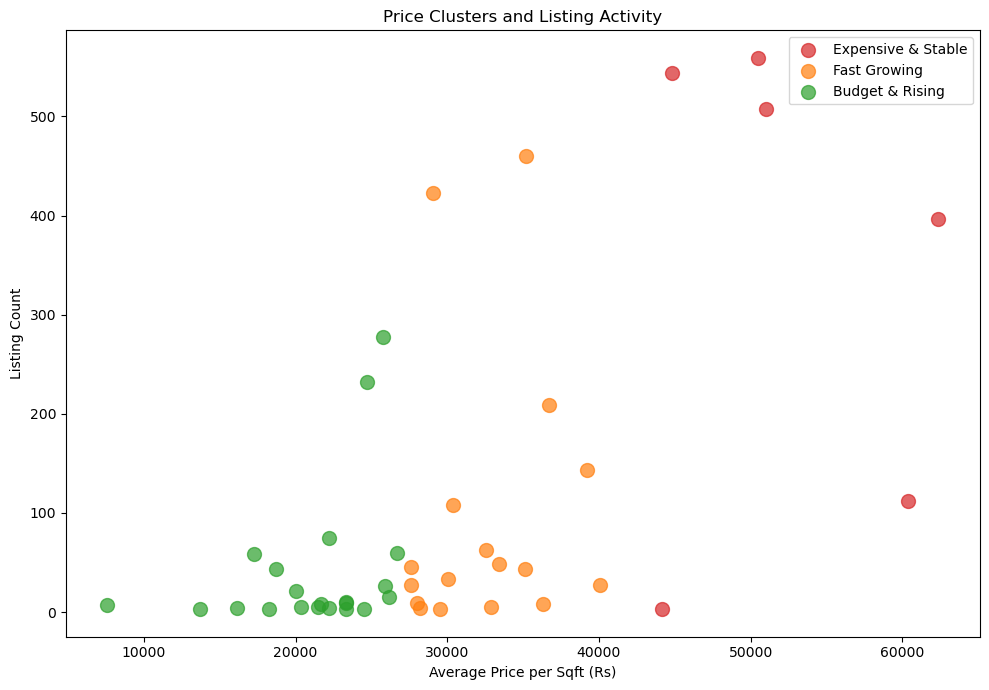

In [ ]:

plt.figure(figsize=(10, 7))
for label, color in colors.items():
    subset = merged[merged["cluster_label"] == label]
    plt.scatter(subset["avg_price_per_sqft"], subset["listing_count"],
                label=label, color=color, s=100, alpha=0.7)
plt.xlabel("Average Price per Sqft (Rs)")
plt.ylabel("Listing Count")
plt.title("Price Clusters and Listing Activity")
plt.legend()
plt.tight_layout()
plt.savefig("chart_cluster_scatter.png", dpi=300, bbox_inches="tight")
plt.show()

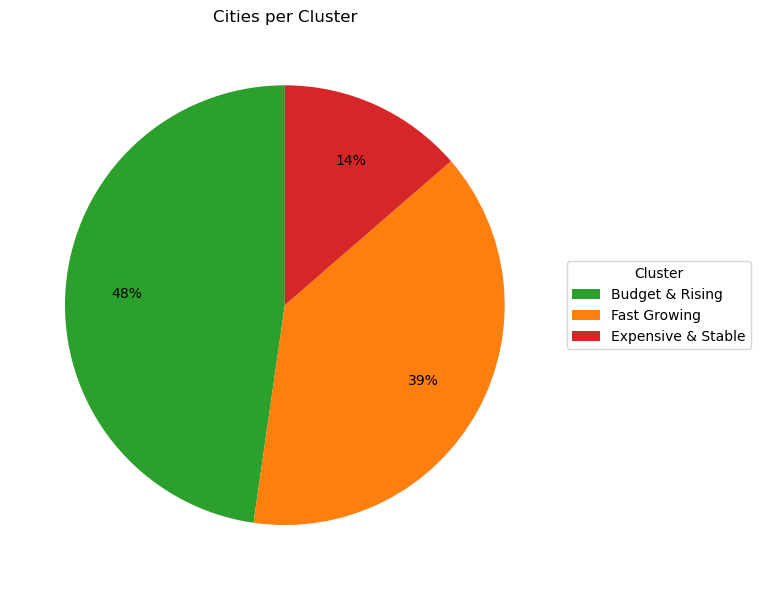

In [ ]:
# cities per cluster
fig, ax = plt.subplots(figsize=(8, 6))
cluster_counts = merged["cluster_label"].value_counts()
wedges, _, _ = ax.pie(
    cluster_counts.values, autopct='%1.0f%%', startangle=90, pctdistance=0.72,
    colors=[colors[label] for label in cluster_counts.index]
)
ax.legend(wedges, cluster_counts.index, title="Cluster",
          loc="center left", bbox_to_anchor=(1.0, 0.5))
ax.set_title("Cities per Cluster")
fig.tight_layout()
fig.savefig("chart_cluster_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

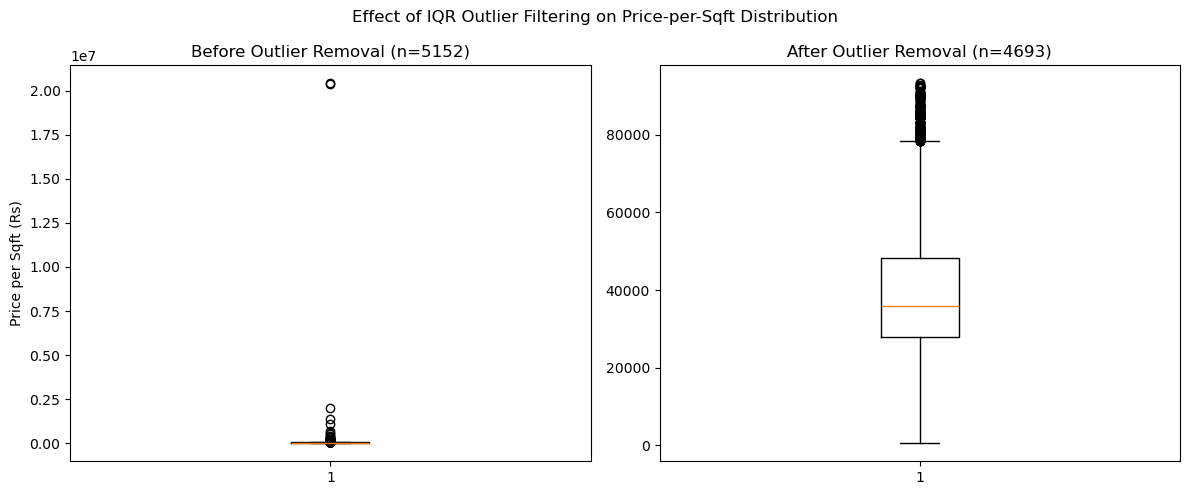

In [ ]:
# before/after outlier removal 
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].boxplot(price_per_sqft_before_outliers, vert=True)
axes[0].set_title(f"Before Outlier Removal (n={len(price_per_sqft_before_outliers)})")
axes[0].set_ylabel("Price per Sqft (Rs)")
axes[1].boxplot(apt["price_per_sqft"], vert=True)
axes[1].set_title(f"After Outlier Removal (n={len(apt)})")
plt.suptitle("Effect of IQR Outlier Filtering on Price-per-Sqft Distribution")
plt.tight_layout()
plt.savefig("chart_outlier_removal.png")
plt.show()

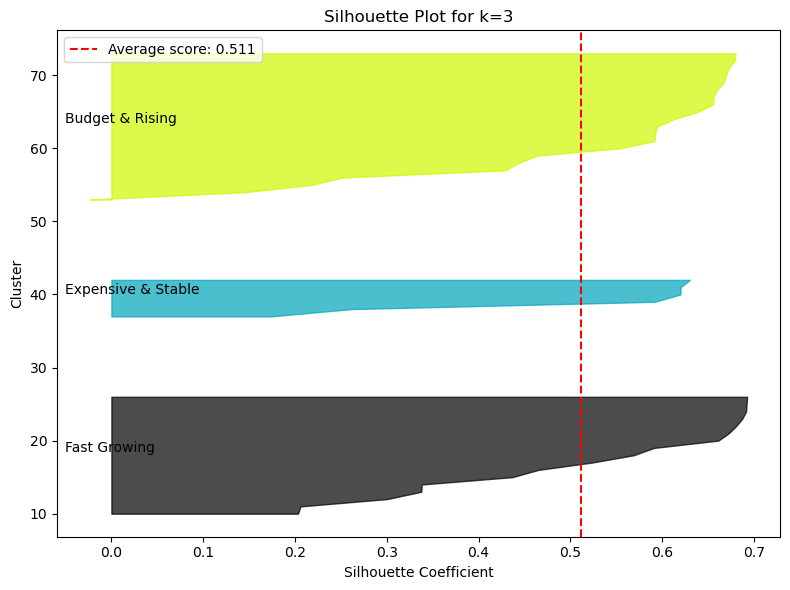

In [ ]:
# Chart 5: silhouette plot 
from matplotlib import cm

sample_silhouette_values = silhouette_samples(X_scaled, city_stats["cluster"])
avg_score = silhouette_score(X_scaled, city_stats["cluster"])

fig, ax = plt.subplots(figsize=(8, 6))
y_lower = 10
for i in sorted(city_stats["cluster"].unique()):
    cluster_silhouette_vals = sample_silhouette_values[city_stats["cluster"] == i]
    cluster_silhouette_vals.sort()
    size = cluster_silhouette_vals.shape[0]
    y_upper = y_lower + size
    color = cm.nipy_spectral(float(i) / 3)
    ax.fill_betweenx(np.arange(y_lower, y_upper), 0, cluster_silhouette_vals,
                      facecolor=color, edgecolor=color, alpha=0.7)
    ax.text(-0.05, y_lower + 0.5 * size, label_map[i])
    y_lower = y_upper + 10

ax.axvline(x=avg_score, color="red", linestyle="--", label=f"Average score: {avg_score:.3f}")
ax.set_xlabel("Silhouette Coefficient")
ax.set_ylabel("Cluster")
ax.set_title("Silhouette Plot for k=3")
ax.legend()
plt.tight_layout()
plt.savefig("chart_silhouette.png")
plt.show()

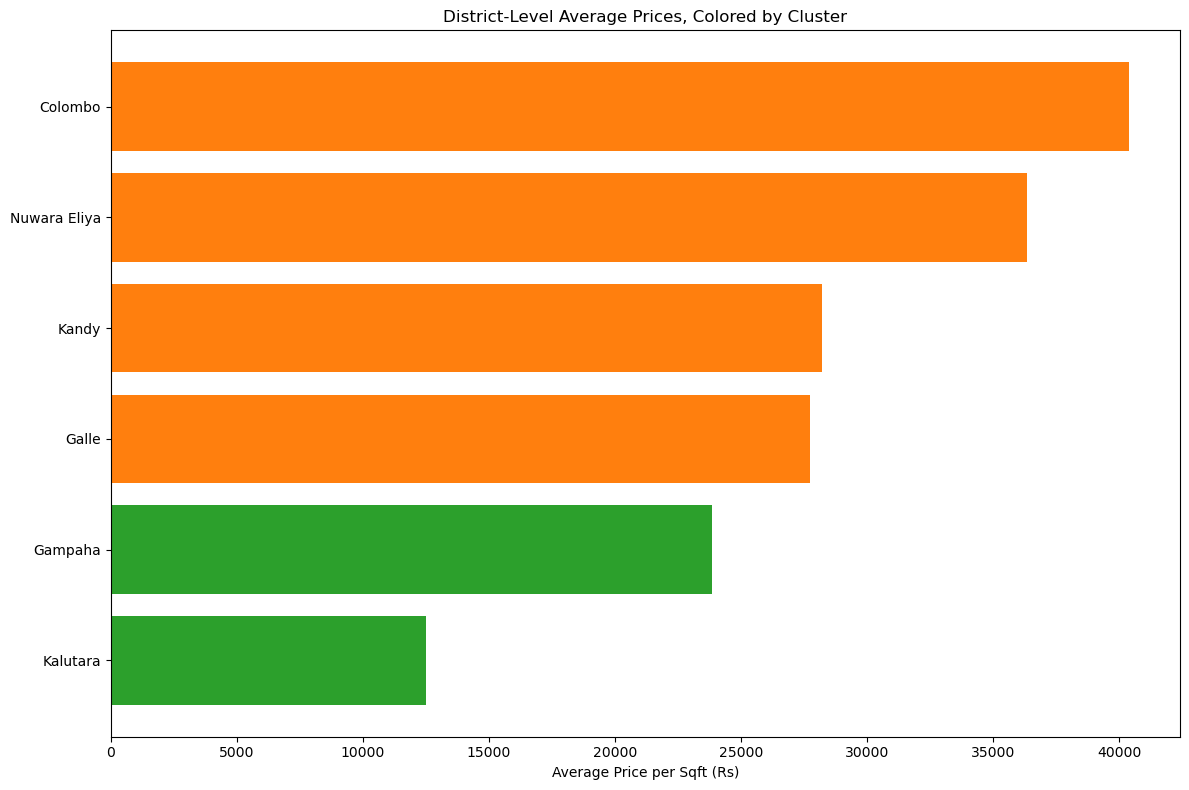

In [ ]:
# Chart 6 : district-level cluster bar chart
plt.figure(figsize=(12, 8))
sorted_districts = district_stats.sort_values("avg_price_per_sqft", ascending=True)
plt.barh(sorted_districts["district"], sorted_districts["avg_price_per_sqft"],
         color=[colors[c] for c in sorted_districts["cluster_label"]])
plt.xlabel("Average Price per Sqft (Rs)")
plt.title("District-Level Average Prices, Colored by Cluster")
plt.tight_layout()
plt.savefig("chart_district_prices.png")
plt.show()

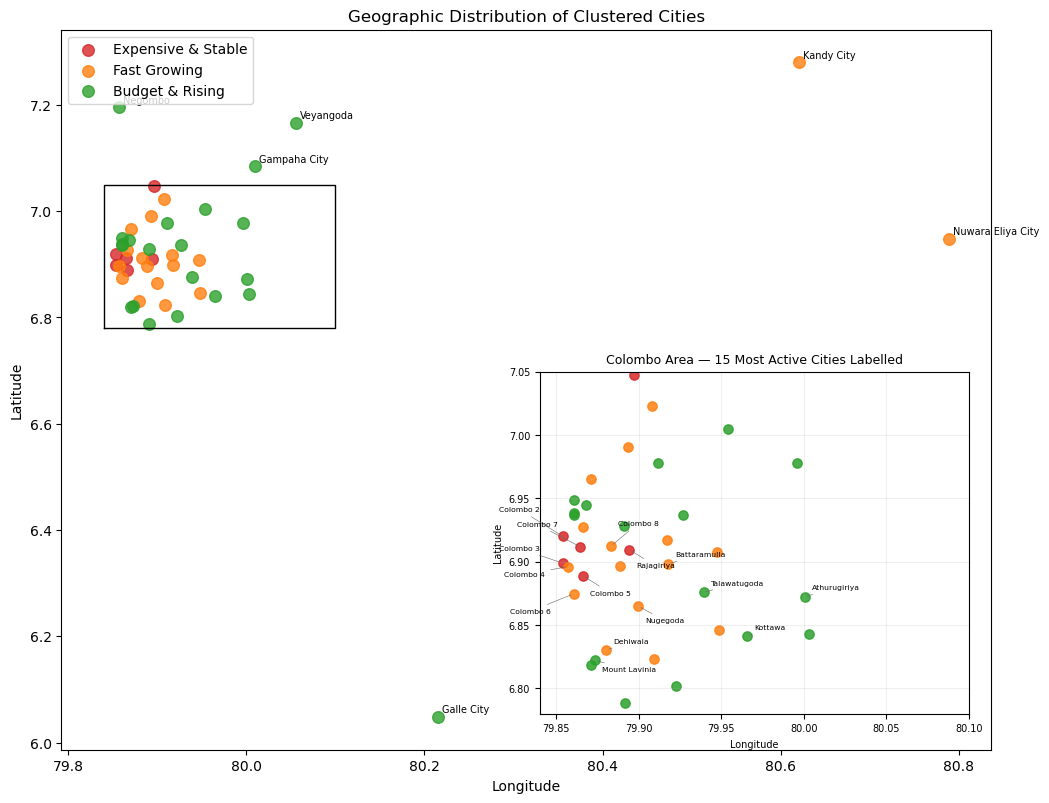

In [10]:
# Chart 7: national view with a Colombo-area inset so dense labels remain readable
fig, ax = plt.subplots(figsize=(11, 9))
metro_bounds = {"lon_min": 79.84, "lon_max": 80.10, "lat_min": 6.78, "lat_max": 7.05}
metro_mask = (
    merged["longitude"].between(metro_bounds["lon_min"], metro_bounds["lon_max"]) &
    merged["latitude"].between(metro_bounds["lat_min"], metro_bounds["lat_max"])
)

for label, color in colors.items():
    subset = merged[merged["cluster_label"] == label]
    ax.scatter(subset["longitude"], subset["latitude"], label=label, color=color, s=70, alpha=0.8)
    for _, row in subset[~subset.index.isin(merged[metro_mask].index)].iterrows():
        ax.annotate(row["city_clean"], (row["longitude"], row["latitude"]), fontsize=7, xytext=(3, 3), textcoords="offset points")

# Mark the area enlarged in the inset.
xs = [metro_bounds["lon_min"], metro_bounds["lon_max"], metro_bounds["lon_max"], metro_bounds["lon_min"], metro_bounds["lon_min"]]
ys = [metro_bounds["lat_min"], metro_bounds["lat_min"], metro_bounds["lat_max"], metro_bounds["lat_max"], metro_bounds["lat_min"]]
ax.plot(xs, ys, color="black", linewidth=1)
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title("Geographic Distribution of Clustered Cities")
ax.legend(loc="upper left")

inset = fig.add_axes([0.56, 0.12, 0.39, 0.38])
metro = merged[metro_mask]
label_candidates = metro.nlargest(15, "listing_count")
label_offsets = {
    "Colombo 2": (-46, 18), "Colombo 3": (-46, 9),
    "Colombo 4": (-46, -7), "Colombo 5": (5, -14),
    "Colombo 6": (-46, -14), "Colombo 7": (-46, 15),
    "Colombo 8": (5, 15), "Rajagiriya": (5, -13),
    "Dehiwala": (5, 5), "Mount Lavinia": (5, -8),
    "Nugegoda": (5, -12)
}
for label, color in colors.items():
    subset = metro[metro["cluster_label"] == label]
    inset.scatter(subset["longitude"], subset["latitude"], color=color, s=45, alpha=0.85)
    for _, row in subset[subset.index.isin(label_candidates.index)].iterrows():
        offset = label_offsets.get(row["city_clean"], (5, 5))
        inset.annotate(row["city_clean"], (row["longitude"], row["latitude"]),
                       fontsize=5.5, xytext=offset, textcoords="offset points",
                       arrowprops={"arrowstyle": "-", "linewidth": 0.4, "color": "0.4"})
inset.set_xlim(metro_bounds["lon_min"], metro_bounds["lon_max"])
inset.set_ylim(metro_bounds["lat_min"], metro_bounds["lat_max"])
inset.set_title("Colombo Area — 15 Most Active Cities Labelled", fontsize=9)
inset.set_xlabel("Longitude", fontsize=7)
inset.set_ylabel("Latitude", fontsize=7)
inset.tick_params(labelsize=7)
inset.grid(alpha=0.2)

fig.subplots_adjust(right=0.97, bottom=0.08)
fig.savefig("chart_geographic_map.png", dpi=300, bbox_inches="tight")
plt.show()

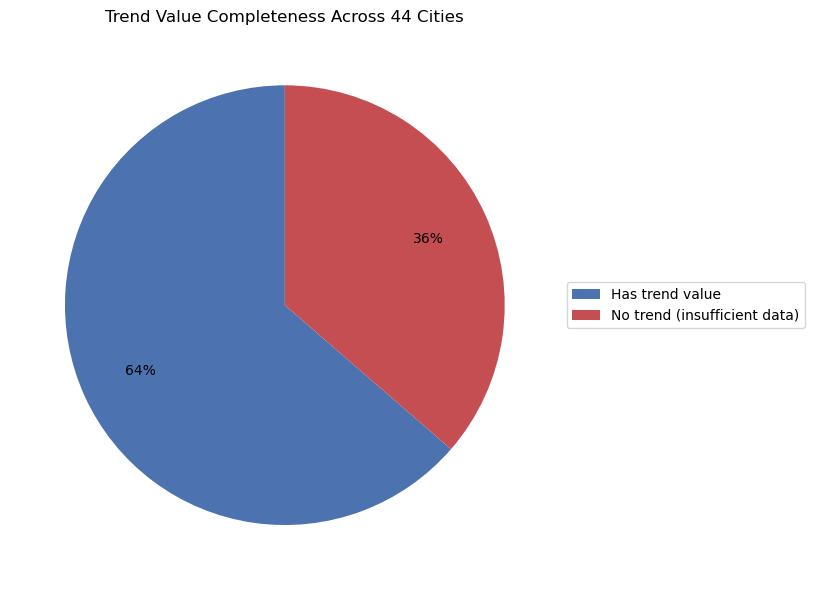

In [11]:
# Chart 8: trend-data coverage, documenting the limitation of the year-on-year proxy
fig, ax = plt.subplots(figsize=(8, 6))
completeness = merged["yoy_trend_pct"].notna().value_counts().reindex([True, False], fill_value=0)
trend_labels = ["Has trend value", "No trend (insufficient data)"]
trend_colors = ["#4c72b0", "#c44e52"]
wedges, _, _ = ax.pie(completeness.values, autopct='%1.0f%%', startangle=90,
                      pctdistance=0.72, colors=trend_colors)
ax.legend(wedges, trend_labels, loc="center left", bbox_to_anchor=(1.0, 0.5))
ax.set_title(f"Trend Value Completeness Across {len(merged)} Cities")
fig.tight_layout()
fig.savefig("chart_trend_completeness.png", dpi=300, bbox_inches="tight")
plt.show()

In [12]:
merged.to_csv("merged_final.csv", index=False)
print(f"Saved merged_final.csv ({len(merged)} cities, {merged.shape[1]} columns)")

Saved merged_final.csv (44 cities, 11 columns)
